- Confusion Matrix
- Precision, Recall, F1
- AUC-ROC
- Regression Metrics
- Cross-validation
- Overfitting & Underfitting
- Bias-Variance Tradeoff
- Regularization
- Hyperparameter Tuning
- Model Selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    learning_curve
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PolynomialFeatures
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier
)

from sklearn.linear_model import (
    LogisticRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("Data/big_mart_sales.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
median_sales = df["Item_Outlet_Sales"].median()

df["Sales_Class"] = (
    df["Item_Outlet_Sales"] >= median_sales
).astype(int)

print("Median Sales:", median_sales)

print(
    df["Sales_Class"].value_counts()
)

Median Sales: 1794.331
Sales_Class
1    4266
0    4257
Name: count, dtype: int64


In [4]:
X_class = df.drop(
    columns=[
        "Item_Outlet_Sales",
        "Sales_Class"
    ]
)

y_class = df["Sales_Class"]

In [5]:
X_class = df.drop(
    columns=[
        "Item_Outlet_Sales",
        "Sales_Class"
    ]
)

y_class = df["Sales_Class"]

In [6]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

In [7]:
numeric_class = X_class.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_class = X_class.select_dtypes(
    include=["object"]
).columns

In [8]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor_class = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_class
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_class
    )
])

In [9]:
rf_classifier = Pipeline([
    (
        "preprocessor",
        preprocessor_class
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_classifier.fit(
    X_train_class,
    y_train_class
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))])),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])

In [10]:
y_pred_class = rf_classifier.predict(
    X_test_class
)

y_prob_class = rf_classifier.predict_proba(
    X_test_class
)[:, 1]

In [11]:
cm = confusion_matrix(
    y_test_class,
    y_pred_class
)

print(cm)

[[650 202]
 [108 745]]


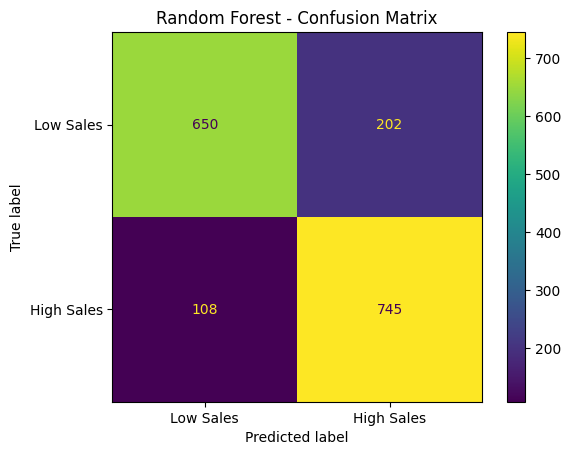

In [12]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Low Sales",
        "High Sales"
    ]
)

disp.plot()

plt.title(
    "Random Forest - Confusion Matrix"
)

plt.show()

In [13]:
precision = precision_score(
    y_test_class,
    y_pred_class
)

In [14]:
recall = recall_score(
    y_test_class,
    y_pred_class
)

In [15]:
f1 = f1_score(
    y_test_class,
    y_pred_class
)

In [16]:
print(
    f"Precision: {precision * 100:.2f}%"
)

print(
    f"Recall: {recall * 100:.2f}%"
)

print(
    f"F1 Score: {f1 * 100:.2f}%"
)

Precision: 78.67%
Recall: 87.34%
F1 Score: 82.78%


In [17]:
accuracy = accuracy_score(
    y_test_class,
    y_pred_class
)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")

Accuracy : 81.82%
Precision: 78.67%
Recall   : 87.34%
F1 Score : 82.78%


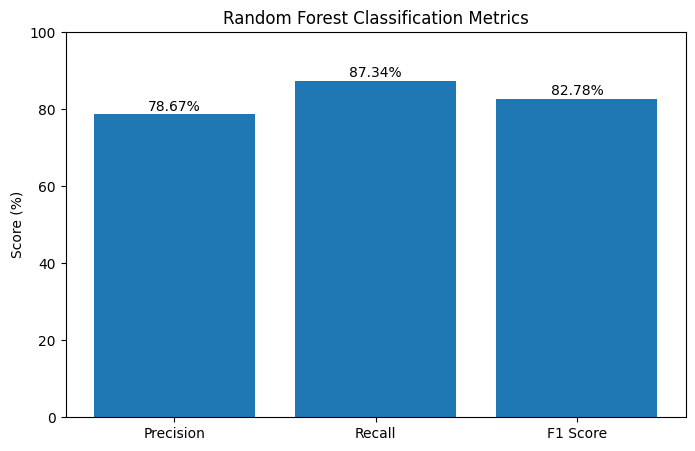

In [18]:
metrics = [
    "Precision",
    "Recall",
    "F1 Score"
]

values = [
    precision * 100,
    recall * 100,
    f1 * 100
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    metrics,
    values
)

plt.ylabel("Score (%)")
plt.title(
    "Random Forest Classification Metrics"
)

plt.ylim(0, 100)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [19]:
auc = roc_auc_score(
    y_test_class,
    y_prob_class
)

print(
    f"AUC: {auc:.4f}"
)

AUC: 0.8839


In [20]:
fpr, tpr, thresholds = roc_curve(
    y_test_class,
    y_prob_class
)

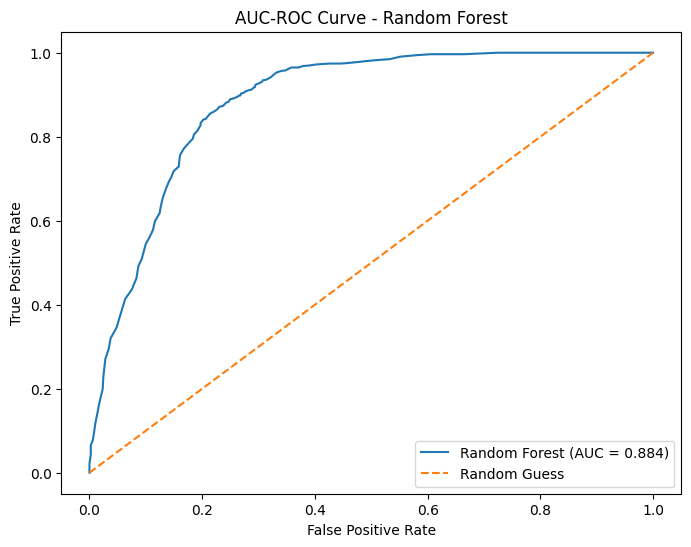

In [21]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "AUC-ROC Curve - Random Forest"
)

plt.legend()

plt.show()

In [22]:
X_reg = df.drop(
    columns=[
        "Item_Outlet_Sales",
        "Sales_Class"
    ]
)

y_reg = df["Item_Outlet_Sales"]

In [23]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [24]:
numeric_reg = X_reg.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_reg = X_reg.select_dtypes(
    include=["object"]
).columns

In [25]:
preprocessor_reg = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]),
        numeric_reg
    ),
    (
        "categorical",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]),
        categorical_reg
    )
])

In [26]:
rf_regressor = Pipeline([
    (
        "preprocessor",
        preprocessor_reg
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_regressor.fit(
    X_train_reg,
    y_train_reg
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [27]:
y_pred_reg = rf_regressor.predict(
    X_test_reg
)

In [28]:
mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

print(
    f"MAE: {mae:.2f}"
)

MAE: 756.67


In [29]:
mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

print(
    f"MSE: {mse:.2f}"
)

MSE: 1184683.35


In [30]:
rmse = np.sqrt(mse)

print(
    f"RMSE: {rmse:.2f}"
)

RMSE: 1088.43


In [31]:
r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print(
    f"R² Score: {r2:.4f}"
)

print(
    f"R² Score: {r2 * 100:.2f}%"
)

R² Score: 0.5641
R² Score: 56.41%


In [32]:
print("=" * 45)
print("RANDOM FOREST REGRESSION")
print("=" * 45)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

RANDOM FOREST REGRESSION
MAE  : 756.67
MSE  : 1184683.35
RMSE : 1088.43
R²   : 0.5641


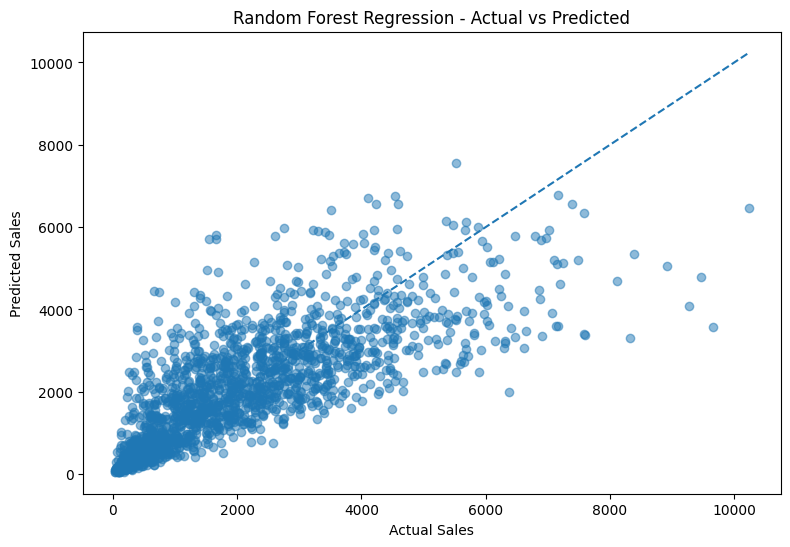

In [33]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.5
)

minimum = min(
    y_test_reg.min(),
    y_pred_reg.min()
)

maximum = max(
    y_test_reg.max(),
    y_pred_reg.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Sales"
)

plt.ylabel(
    "Predicted Sales"
)

plt.title(
    "Random Forest Regression - Actual vs Predicted"
)

plt.show()

In [34]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [35]:
cv_scores = cross_val_score(
    rf_classifier,
    X_class,
    y_class,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [36]:
cv_scores = cross_val_score(
    rf_classifier,
    X_class,
    y_class,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [37]:
print(
    "Cross-validation scores:"
)

print(cv_scores)

print(
    f"\nMean Accuracy: "
    f"{cv_scores.mean() * 100:.2f}%"
)

print(
    f"Standard Deviation: "
    f"{cv_scores.std() * 100:.2f}%"
)

Cross-validation scores:
[0.80293255 0.81231672 0.82170088 0.82394366 0.81690141]

Mean Accuracy: 81.56%
Standard Deviation: 0.75%


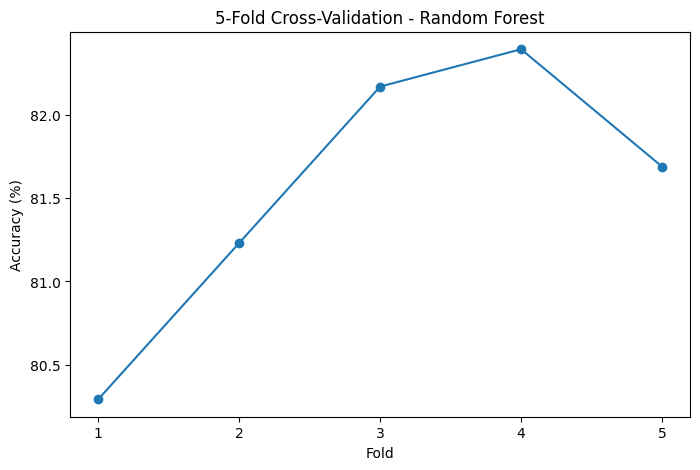

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    cv_scores * 100,
    marker="o"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")

plt.title(
    "5-Fold Cross-Validation - Random Forest"
)

plt.xticks(range(1, 6))

plt.show()

In [39]:
train_accuracy = rf_classifier.score(
    X_train_class,
    y_train_class
)

test_accuracy = rf_classifier.score(
    X_test_class,
    y_test_class
)

print(
    f"Training Accuracy: {train_accuracy * 100:.2f}%"
)

print(
    f"Testing Accuracy : {test_accuracy * 100:.2f}%"
)

Training Accuracy: 100.00%
Testing Accuracy : 81.82%


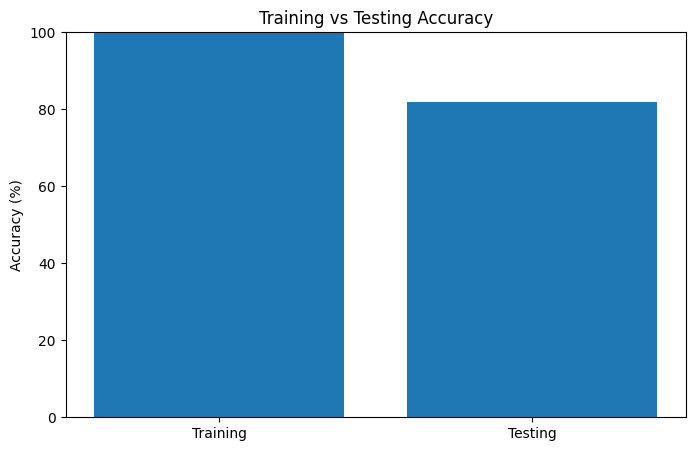

In [40]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Training", "Testing"],
    [
        train_accuracy * 100,
        test_accuracy * 100
    ]
)

plt.ylabel("Accuracy (%)")

plt.title(
    "Training vs Testing Accuracy"
)

plt.ylim(0, 100)

plt.show()

In [41]:
gap = train_accuracy - test_accuracy

print(
    f"Train-Test Gap: {gap * 100:.2f}%"
)

if gap > 0.10:
    print("Possible Overfitting")

elif train_accuracy < 0.70:
    print("Possible Underfitting")

else:
    print("Model appears reasonably fitted")

Train-Test Gap: 18.18%
Possible Overfitting


In [42]:
depths = [
    1,
    2,
    3,
    5,
    10,
    15,
    None
]

train_scores = []
test_scores = []

In [43]:
for depth in depths:

    model = Pipeline([
        (
            "preprocessor",
            preprocessor_class
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=depth,
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    model.fit(
        X_train_class,
        y_train_class
    )

    train_scores.append(
        model.score(
            X_train_class,
            y_train_class
        )
    )

    test_scores.append(
        model.score(
            X_test_class,
            y_test_class
        )
    )

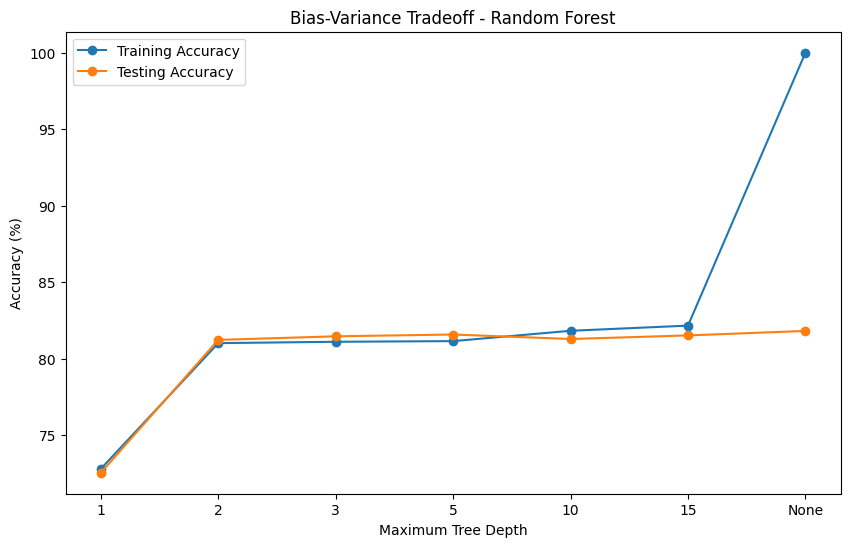

In [44]:
depth_labels = [
    "1",
    "2",
    "3",
    "5",
    "10",
    "15",
    "None"
]

plt.figure(figsize=(10, 6))

plt.plot(
    depth_labels,
    np.array(train_scores) * 100,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depth_labels,
    np.array(test_scores) * 100,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")

plt.ylabel("Accuracy (%)")

plt.title(
    "Bias-Variance Tradeoff - Random Forest"
)

plt.legend()

plt.show()

In [45]:
logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor_class
    ),
    (
        "model",
        LogisticRegression(
            C=1.0,
            max_iter=2000,
            random_state=42
        )
    )
])

In [46]:
logistic_model.fit(
    X_train_class,
    y_train_class
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [47]:
logistic_pred = logistic_model.predict(
    X_test_class
)

logistic_accuracy = accuracy_score(
    y_test_class,
    logistic_pred
)

print(
    f"Logistic Regression Accuracy: "
    f"{logistic_accuracy * 100:.2f}%"
)

Logistic Regression Accuracy: 81.23%


In [48]:
C_values = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

regularization_scores = []

for C in C_values:

    model = Pipeline([
        (
            "preprocessor",
            preprocessor_class
        ),
        (
            "model",
            LogisticRegression(
                C=C,
                max_iter=2000,
                random_state=42
            )
        )
    ])

    model.fit(
        X_train_class,
        y_train_class
    )

    score = model.score(
        X_test_class,
        y_test_class
    )

    regularization_scores.append(
        score
    )

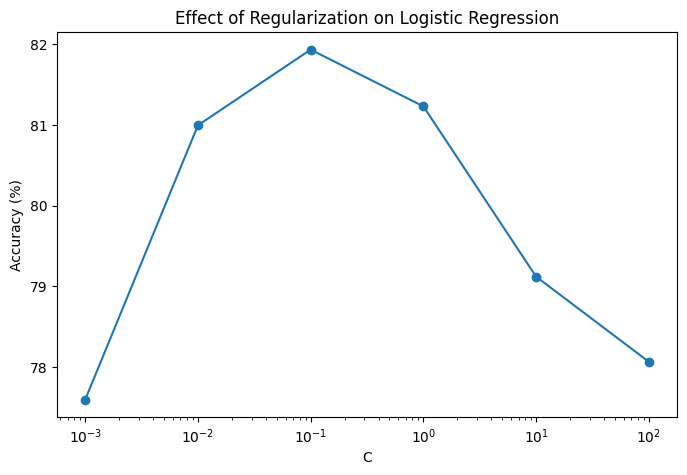

In [49]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    C_values,
    np.array(regularization_scores) * 100,
    marker="o"
)

plt.xlabel("C")

plt.ylabel("Accuracy (%)")

plt.title(
    "Effect of Regularization on Logistic Regression"
)

plt.show()

In [50]:
param_grid = {
    "model__n_estimators": [
        50,
        100,
        200
    ],

    "model__max_depth": [
        None,
        5,
        10,
        15
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [51]:
grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [52]:
grid_search.fit(
    X_train_class,
    y_train_class
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(stra...
                                                                         Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10, 15],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [50, 100, 200]},
             scoring='f1', verbose=1)

In [53]:
print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}


In [54]:
best_model = grid_search.best_estimator_

tuned_prediction = best_model.predict(
    X_test_class
)

tuned_accuracy = accuracy_score(
    y_test_class,
    tuned_prediction
)

tuned_precision = precision_score(
    y_test_class,
    tuned_prediction
)

tuned_recall = recall_score(
    y_test_class,
    tuned_prediction
)

tuned_f1 = f1_score(
    y_test_class,
    tuned_prediction
)

print(
    f"Accuracy : {tuned_accuracy * 100:.2f}%"
)

print(
    f"Precision: {tuned_precision * 100:.2f}%"
)

print(
    f"Recall   : {tuned_recall * 100:.2f}%"
)

print(
    f"F1 Score : {tuned_f1 * 100:.2f}%"
)

Accuracy : 82.52%
Precision: 79.24%
Recall   : 88.16%
F1 Score : 83.46%


In [55]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [56]:
model_results = []

for name, model in models.items():

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor_class
        ),
        (
            "model",
            model
        )
    ])

    scores = cross_val_score(
        pipeline,
        X_class,
        y_class,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    model_results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std()
    })

In [57]:
model_results_df = pd.DataFrame(
    model_results
)

model_results_df[
    "Mean Accuracy"
] *= 100

model_results_df[
    "Std"
] *= 100

display(
    model_results_df.sort_values(
        "Mean Accuracy",
        ascending=False
    )
)

,Model,Mean Accuracy,Std
2,Gradient Boosting,82.342028,0.648831
1,Random Forest,81.426769,0.179771
0,Logistic Regression,81.368145,0.895185


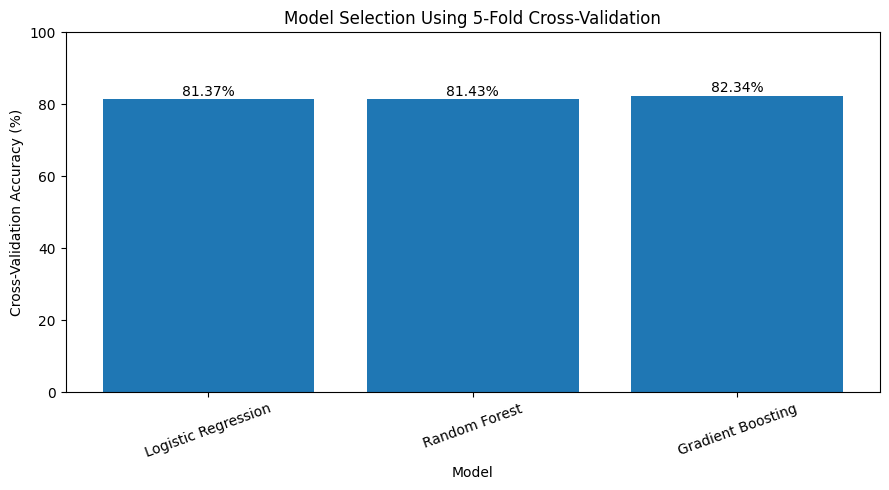

In [58]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    model_results_df["Model"],
    model_results_df["Mean Accuracy"]
)

plt.ylabel(
    "Cross-Validation Accuracy (%)"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Model Selection Using 5-Fold Cross-Validation"
)

plt.ylim(0, 100)

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

In [59]:
train_sizes, train_scores, validation_scores = learning_curve(
    rf_classifier,
    X_class,
    y_class,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),
    n_jobs=-1
)

In [60]:
train_mean = train_scores.mean(axis=1)

validation_mean = validation_scores.mean(axis=1)

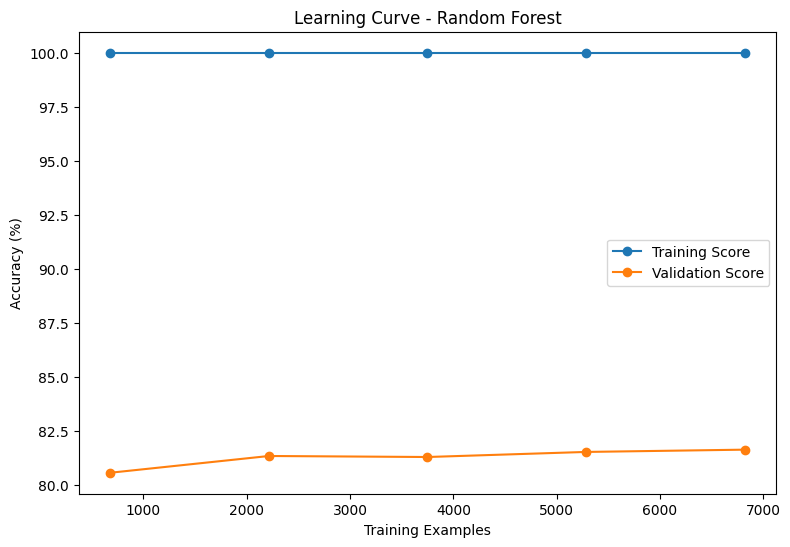

In [61]:
plt.figure(figsize=(9, 6))

plt.plot(
    train_sizes,
    train_mean * 100,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    validation_mean * 100,
    marker="o",
    label="Validation Score"
)

plt.xlabel(
    "Training Examples"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Learning Curve - Random Forest"
)

plt.legend()

plt.show()

In [62]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],

    "Random Forest": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

final_results[
    "Random Forest"
] *= 100

display(final_results)

,Metric,Random Forest
0,Accuracy,81.818182
1,Precision,78.669483
2,Recall,87.338804
3,F1 Score,82.777778
4,AUC,88.387574
